качаем библиотеки

In [2]:
import pandas as pd
import numpy as np

import statistics
import statsmodels.api as sm

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import norm
from scipy.stats import t

#### Проект
Наша кампания ранне имела всего один продукт, он был запущен давно. У нас есть записи сколько выручки нам приносил этот продукт за каждый день его работы. Пару месяцев назад кампания запустила второй продукт, и так же ежедневно фиксировала выручку которую он нам приносил. Данные по выручкам сохранены ниже в переменных product1 и product2.<br>
Наша задача сделать полный анализ на основе всего лишь этих двух списках.

In [3]:
### для загрузки данных
with open(r'materials/project.txt', 'r') as fp:
    for i, line in enumerate(fp):
        if i == 0:
            product1 = [int(i) for i in line.split(' ')]
        if i == 1:
            product2 = [int(i) for i in line.split(' ')]

fp.close()

**Задача 1**<br>
подсчитайте среднее арифметическое (mean), медиану и моду для обоих списков: product1 и product2

In [4]:
mean_product1 = np.mean(product1)
mean_product2 = np.mean(product2)

median_product1 = np.median(product1)
median_product2 = np.median(product2)

mode_product1 = statistics.mode(product1)
mode_product2 = statistics.mode(product2)

print(f"Product 1")
print(f"Mean: {mean_product1}")
print(f"Median: {median_product1}")
print(f"Mode: {mode_product1}")
print(f"\nProduct 2")
print(f"Mean: {mean_product2}")
print(f"Median: {median_product2}")
print(f"Mode: {mode_product2}")

Product 1
Mean: 199.103
Median: 198.5
Mode: 186

Product 2
Mean: 193.5
Median: 194.5
Mode: 227


Какая из трех метрик будет наименее показательной, и почему?<br>
На основе оставшихся двух метрик какой продукт в среднем приносит больше выручки?

In [ ]:
# Mode - наименее показательная, так как в product 2 это может быть просто самое часто повторяющееся число 
# может быть, что в Product 2 все остальные показатели кроме 227 встречаются по одному разу, а 227 всего лишь два раза например
# На основе mean и median, Product 1 в среднем приносит больше выручки

**Задача 2**<br>
подсчитайте стандартное отклонение и скажите оценка какого продукта является более точной?

In [6]:
std_product1 = np.std(product1)
std_product2 = np.std(product2)
print(f"Product 1 std: {std_product1:.2f}")
print(f"Product 2 std: {std_product2:.2f}")

Product 1 std: 28.79
Product 2 std: 29.59


In [ ]:
# стандартное отклонение Product 1 меньше, значит оценка более точная

**Задача 3**<br>
Нарисуйте распределение вероятности выручки для продукта1 и для продукта2.<br>
Можете использовать гистограмму или kdeplot

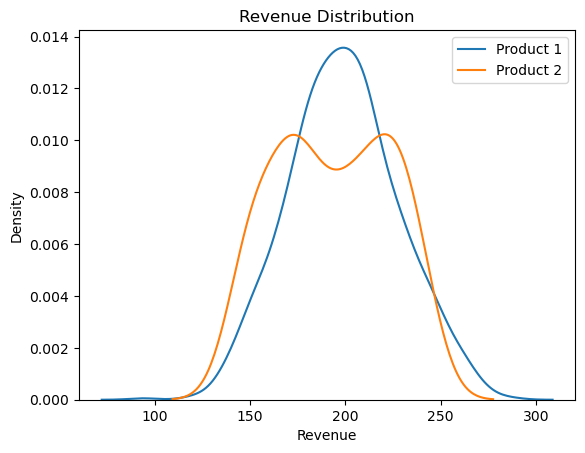

In [7]:
sns.kdeplot(product1, label = "Product 1")
sns.kdeplot(product2, label = "Product 2")

plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Density")
plt.legend()

plt.show()

**Задача 4**<br>
Посчитайте размах выручки для продукта1 и для продукта2<br>
Сходится ли разница в размахах и разница в стандартных отклонениях, какая может быть причина?

In [8]:
range_product1 = max(product1) - min(product1)
range_product2 = max(product2) - min(product2)

print(f"Range of Product 1: {range_product1}")
print(f"Range of Product 2: {range_product2}")

Range of Product 1: 193
Range of Product 2: 97


In [ ]:
# std двух продуктов очень близки друг к другу, а размах сильно отличается, возможно в Product 1 есть outliers

**Задача 5**<br>
Посчитайте межквартильный разммах IQR для продукта1 и продукта2<br>
Теперь убрав выбросы что мы можем сказать о разбросе данных?

In [10]:
q1_product1 = np.percentile(product1, 25)
q3_product1 = np.percentile(product1, 75)
iqr_product1 = q3_product1 - q1_product1

q1_product2 = np.percentile(product2, 25)
q3_product2 = np.percentile(product2, 75)
iqr_product2 = q3_product2 - q1_product2

print(f"IQR of Product 1: {iqr_product1}")
print(f"IQR of Product 2: {iqr_product2}")

IQR of Product 1: 38.25
IQR of Product 2: 51.0


In [13]:
lower_product1 = q1_product1 - 1.5 * iqr_product1
upper_product1 = q3_product1 + 1.5 * iqr_product1

lower_product2 = q1_product2 - 1.5 * iqr_product2
upper_product2 = q3_product2 + 1.5 * iqr_product2

drop_product1 = [x for x in product1 if lower_product1 <= x <= upper_product1]
drop_product2 = [x for x in product2 if lower_product2 <= x <= upper_product2]

new_range_product1 = max(drop_product1) - min(drop_product1)
new_range_product2 = max(drop_product2) - min(drop_product2)

print(f"New Range of Product 1: {new_range_product1}")
print(f"New Range of Product 2: {new_range_product2}")

New Range of Product 1: 151
New Range of Product 2: 97


In [ ]:
# Range у Product 1 стал меньше и ближе к размаху Product 2, значит большая разница была из-за выбросов

**Задача 6**<br>
Нарисуйте box-plot для продукта1 и с рисунка скажите при каких значениях начинаются выбросы

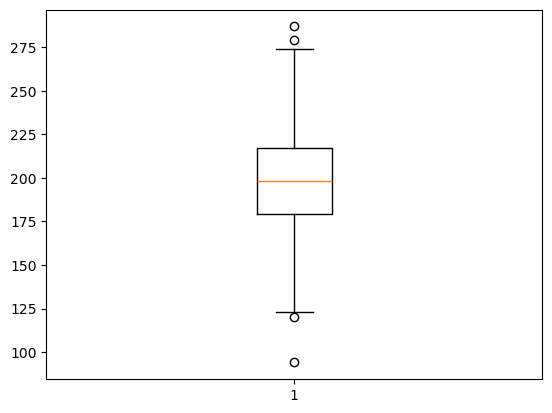

121.625 274.625


In [15]:
plt.boxplot(product1)
plt.show()

print(lower_product1, upper_product1)

In [ ]:
# Как и нарисовано в boxplot, выбросы начинаются на тех же значениях, которые я выше посчитала в lower bound и upper bound

**Задача 7**<br>
Нарисуйте QQ plot выручки для обоих продуктов<br>
Какое из распределений является нормальным?

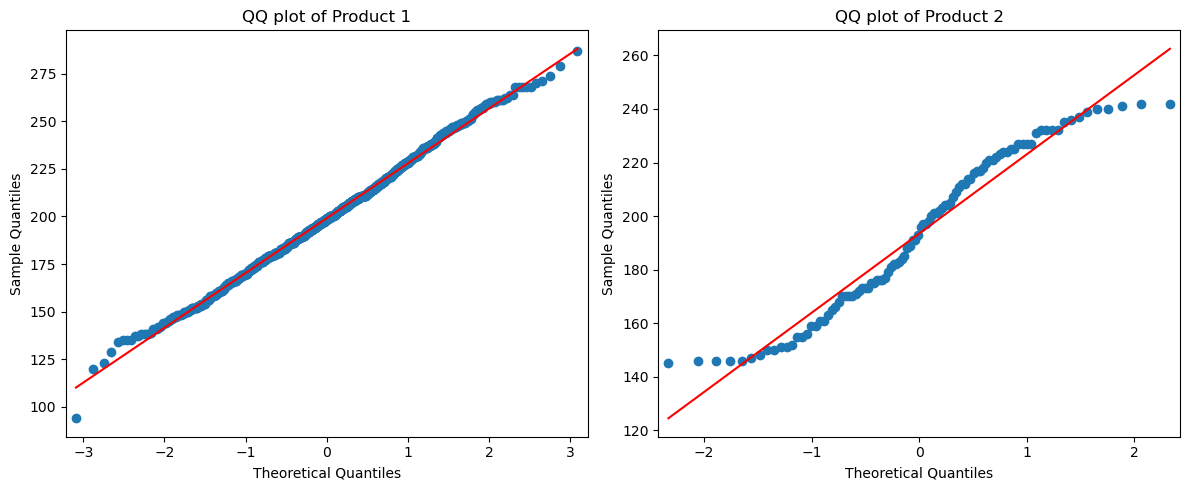

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sm.qqplot(np.array(product1), line='s', ax=axes[0])
axes[0].set_title("QQ plot of Product 1")

sm.qqplot(np.array(product2), line='s', ax=axes[1])
axes[1].set_title("QQ plot of Product 2")

plt.tight_layout()
plt.show()

Каких значений много или наоборот не достает в продукте2 чтобы значения стали нормально распределенными?

In [ ]:
# в Product 2 не хватает крайних значений, и слишком много значений в центральной области 

**Задача 8**<br>
И так мы знаем что выручка продукта1 является нормально распредленной, переведите все значения в стандартное нормальное распределение используя текущие mean и std<br>
создайте новую переменнуя и запишите новые значения туда

In [20]:
product1_changed = (np.array(product1) - mean_product1) / std_product1

Нарисуйте kdeplot нового стандартного распределения

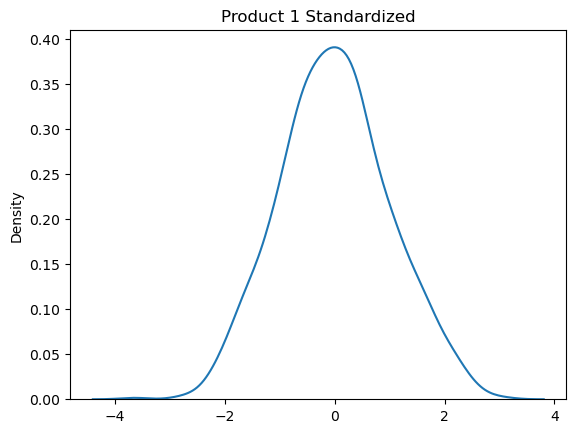

In [21]:
sns.kdeplot(product1_changed)
plt.title("Product 1 Standardized")
plt.show()

**Задача 9**<br>
Подсчитайте точку слева от которой будет 1% всей вероятности распределения

In [28]:
left = norm.ppf(0.01)
print(left)

-2.3263478740408408


Первое значение в списке product1 равно 94. Когда мы преобразуем список в стандартное нормальное распределение, 94 преобразуется в -3.65<br>
Что нам говорит это число, особенно при сравнении с точкой которую мы только что подсчитали?

In [ ]:
# Это означает, что 94 очень редкое значение и находится слева, далеко за пределами 1% самых малых значений

**Задача 10**<br>
Продукт2 новый, но уже достаточно стабилизирвался за эти месяцы. Мы хотим знать сколько он будет в среднем нам приносить ежедневно выручки и в будущем.<br>
Дайте точечную оценку средней выручке продукта2

In [24]:
print(f"Точечная оценка: {mean_product2}")

Точечная оценка: 193.5


Подсчитайте 95% доверительный интервал

In [26]:
ul = norm.ppf(0.975, mean_product2, std_product2)
ll = norm.ppf(0.025, mean_product2, std_product2)

print(f"Доверительный интервал от {ll} до {ul}")

Доверительный интервал от 135.50658992518277 до 251.49341007481723


**Задача11**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 выше чем 197.5

In [31]:
from scipy.stats import ttest_1samp

t_statistic, p_value = ttest_1samp(product1, 197.5)

p_value = p_value / 2

print(f"t_stat: {t_statistic}")
print(f"p_val: {p_value}")

alpha = 0.05
if p_value < alpha: 
    print(f"Средняя выручка у продукта1 выше чем 197.5")
else: 
    print(f"Нет оснований утверждать, что выручка у продукта1 выше чем 197.5")

t_stat: 1.7596034376105127
p_val: 0.039390559624344984
Средняя выручка у продукта1 выше чем 197.5


Какой это был типа АБ теста?

In [ ]:
# one-sample t-test

**Задача12**<br>
Проведите АБ тест с уровнем значимости 5% что средняя выручка у продукта1 и у продукта2 равны

In [32]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(product1, product2)
print(f"t_stat: {t_statistic}")
print(f"p_val: {p_value}")

alpha = 0.05
if p_value < alpha: 
    print(f"Средние различаются")
else: 
    print(f"Нет оснований утверждать, что средние различаются")

t_stat: 1.8489503287555282
p_val: 0.06473365137046305
Нет оснований утверждать, что средние различаются


In [33]:
from scipy.stats import mannwhitneyu

u_statistic, p_value = mannwhitneyu(product1, product2, alternative='two-sided')

alpha = 0.05
if p_value < alpha: 
    print(f"Есть значимая разница между продуктами")
else: 
    print(f"Нет значимой разницы между продуктами")

Нет значимой разницы между продуктами
